In [2]:
import pyscf
from pyscf import fci,scf
import numpy as np
from pyscf.fci import cistring


mol = pyscf.M(
    atom = 'O 0 0 0; O 0 0 1.1',  
    basis = 'sto-3g',
    symmetry = True,
    spin = 2,
    
)
myhf = mol.RHF().run()

# #
# # create an FCI solver based on the SCF object
# #
cisolver = pyscf.fci.FCI(myhf)
cie,civ=cisolver.kernel()
print(civ )
num_orbitals = myhf.mo_coeff.shape[1]
print(num_orbitals)
num_alpha_electrons, num_beta_electrons = mol.nelec
print(num_alpha_electrons,num_beta_electrons)
print(civ.shape)

# #
# # create an FCI solver based on the SCF object
# #

# myuhf = mol.UHF().run()
# cisolver = fci.FCI(myuhf)
# e,vec=cisolver.kernel()
# print(e,vec)

#
# # create an FCI solver based on the given orbitals and the num. electrons and
# # spin of the mol object
# #
# cisolver = pyscf.fci.FCI(mol, myhf.mo_coeff)
# print('E(FCI) = ', cisolver.kernel())

alpha_state=np.concatenate((np.ones(num_alpha_electrons),np.zeros(num_orbitals-num_alpha_electrons)),
                           axis=0)
beta_state=np.concatenate((np.ones(num_beta_electrons),np.zeros(num_orbitals-num_beta_electrons)),
                           axis=0)
print(alpha_state,beta_state)


# def generate_states(num_orbitals,num_electrons):
#     num_holes=num_orbitals-num_electrons
#     g_state=np.concatenate((np.ones(num_electrons),np.zeros(num_holes)),
#                            axis=0)
#     all=np.array(g_state)
#     max_excitements=np.min(num_electrons,num_holes)
#     for k in range(1,max_excitements+1):
#         for i in range(0,num_electrons):
#             for j in range(num_electrons,num_orbitals):

stra=cistring.addr2str(10,7,10)
print(bin(stra))

converged SCF energy = -147.590894030918
[[ 9.19854131e-02  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  4.92786279e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  2.20629094e-04 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.48841749e-05  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
10
9 7
(10, 120)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 0.] [1. 1. 1. 1. 1. 1. 1. 0. 0. 0.]
0b101101111


In [3]:
def convert_binary_to_array(strfil, num_orbitals):
    binary_str=str(bin(strfil))
    binary_str = binary_str[2:]
    binary_array = [int(bit) for bit in binary_str]
    leading_zeros = num_orbitals - len(binary_array)
    result_array = [0] * leading_zeros + binary_array
    
    return result_array

# Test the function
# binary_str = "0b11101111"
# result = convert_binary_to_array(stra,10)
# print(result)


In [4]:
from itertools import combinations
from jax import numpy as jnp

# def generate_states(num_orbitals,num_electrons):
#     configs = []
#     for indices in combinations(range(num_orbitals), num_electrons):
#         box_config = [1 if i in indices else 0 for i in range(num_orbitals)]
#         configs.append(box_config)
#     return np.array(configs)

def generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,ci):
    # alpha_states=np.concatenate((np.ones(num_alpha_electrons),np.zeros(num_orbitals-num_alpha_electrons)),
    #                        axis=0)
    # beta_states=np.concatenate((np.ones(num_beta_electrons),np.zeros(num_orbitals-num_beta_electrons)),
    #                        axis=0)
    
    # alpha_states=generate_states(num_orbitals,num_alpha_electrons)
    # beta_states=generate_states(num_orbitals,num_beta_electrons)
    x=[]
    y=[]
    # print(ci.shape[0])
    for i in range(ci.shape[0]):
        for j in range(ci.shape[1]):
                
            y.append(ci[i,j])
            #print(num_orbitals,num_alpha_electrons,i)
            orba=cistring.addr2str(num_orbitals,num_alpha_electrons,i)
            orbb=cistring.addr2str(num_orbitals,num_beta_electrons,j)
            
            orba=convert_binary_to_array(orba,num_orbitals)
            orbb=convert_binary_to_array(orbb,num_orbitals)
            x.append(np.concatenate((orba,orbb),axis=0))
    x=jnp.array(x)
    y=jnp.array(y)
    return x,y



# num_orbs = 10
# num_e = 7
# config_list = generate_states(num_orbs, num_e)

# print(generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ))



In [5]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
from jax import random
import matplotlib.pyplot as plt

class NN1(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=64)(x)  
        x = nn.relu(x)
        x = nn.Dense(features=1)(x) 
        x = nn.tanh(x)    
        # print(x.shape)
        return x             


def create_model(rng, input_shape):
    model = NN1()
    variables = model.init(rng, jnp.ones(input_shape))
    return model, variables

# Define the mean squared error (MSE) loss function
def mse_loss(params, apply_fn, x, y):
    preds = apply_fn({'params': params}, x)
    return jnp.mean((preds - y) ** 2)


@jax.jit
def train_step(state, batch):
    def loss_fn(params):
        x, y = batch
        loss = mse_loss(params, state.apply_fn, x, y)
        return loss
    grads = jax.grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss_fn(state.params)


def create_train_state(rng, model, variables):
    tx = optax.adam(learning_rate=0.001)
    return train_state.TrainState.create(apply_fn=model.apply, params=variables['params'], tx=tx)


# Check Neural network functions
# def generate_random_data(rng, num_samples, input_size):    
#     x = random.randint(rng, (num_samples, input_size), 0, 2)
#     y = random.uniform(rng, (num_samples, 1), float,-1, 1)
#     return x, y




Epoch 1, Loss: 0.007766211871057749
Epoch 2, Loss: 0.003123381407931447
Epoch 3, Loss: 0.0018966577481478453
Epoch 4, Loss: 0.0014936027582734823
Epoch 5, Loss: 0.0012835721718147397
Epoch 6, Loss: 0.0010767605854198337
Epoch 7, Loss: 0.0009841545252129436
Epoch 8, Loss: 0.0009360648109577596
Epoch 9, Loss: 0.000903563923202455
Epoch 10, Loss: 0.0008952608914114535
Epoch 11, Loss: 0.000871436670422554
Epoch 12, Loss: 0.000855790451169014
Epoch 13, Loss: 0.000834201171528548
Epoch 14, Loss: 0.0008209897787310183
Epoch 15, Loss: 0.0008073511999100447
Epoch 16, Loss: 0.000790023768786341
Epoch 17, Loss: 0.0007672047358937562
Epoch 18, Loss: 0.0007322950405068696
Epoch 19, Loss: 0.0006912121316418052
Epoch 20, Loss: 0.0006499359733425081
Epoch 21, Loss: 0.000606908870395273
Epoch 22, Loss: 0.0005574159440584481
Epoch 23, Loss: 0.0005268393433652818
Epoch 24, Loss: 0.0004840393958147615
Epoch 25, Loss: 0.00042422988917678595
Epoch 26, Loss: 0.00036747934063896537
Epoch 27, Loss: 0.000335139

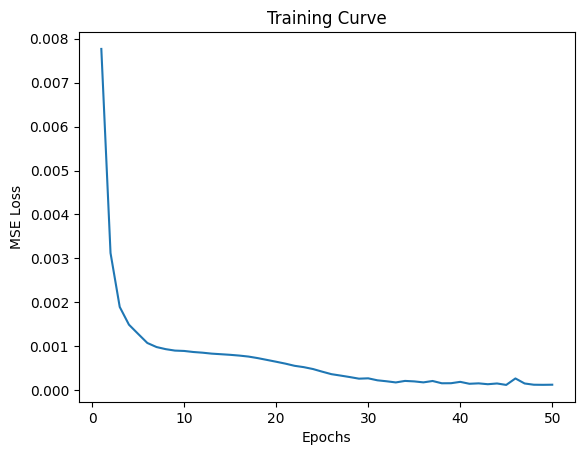

Training complete


In [6]:
# Main function
def main():
    rng = random.PRNGKey(7)
    
    x_train, y_train = generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ)
    input_size = 2*num_orbitals # Example input size
    num_samples = len(y_train) # Number of training samples
    
    model, variables = create_model(rng, (input_size,))
    state = create_train_state(rng, model, variables)
    
    # Training loop
    num_epochs = 50
    batch_size = 1
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for i in range(0, num_samples, batch_size):
            batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
            state, loss = train_step(state, batch)
            epoch_loss += loss
        
        average_epoch_loss = epoch_loss / (num_samples // batch_size)
        train_losses.append(average_epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")
    
    # Plotting the training curve
    plt.plot(range(1, num_epochs + 1), train_losses)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training Curve')
    plt.show()
    #plt.plot(x_tra,y_train)
    print("Training complete")

if __name__ == "__main__":
    main()

In [7]:
class BACKFLOW(nn.Module):
    # features: Sequence[int] 
    num_orbital:int
    num_electron:int

    # def setup(self):
    #    self.layers = [nn.Dense(n) for n in self.features]
    @nn.compact
    def __call__(self, x):
        # for i, lyr in enumerate(self.layers):
        #   x = lyr(x)
        #   if i != len(self.layers) - 1:
        #     x = nn.relu(x) 
        # # TODO: select corresponding rows and columns of the matrix
        # MLP
        # x = jnp.reshape(x,(20,1))
        y = jnp.copy(x)
        #print(y)
        #print("yshape",y.shape,y)
        selected_configs =jnp.where(y==1)[0]
        # for j, yj in enumerate(y):
        #     # print(yj)
        #     if yj==1:
        #         selected_configs.append(j)
        
                
        x = nn.Dense(features=8)(x)  
        x = nn.relu(x)
        
        #Backflow
        #print(type(x),x.shape)
        x = nn.DenseGeneral(features=(self.num_orbital,self.num_electron))(x)
        #print(x.shape)
        # print(x.shape,self.num_orbital,self.num_electron,)
        #print(type(x),x.shape)
        x = x[:,selected_configs , :]
        #print(jnp.array(selected_configs).shape)
        
        #x=nn.Dense(features=1)(x)
        # x = jnp.linalg.det(x)
        # x = jnp.array([x])
        #print(type(x),x.shape)
        return x

def create_model(rng, input_shape,num_electrons): #input shape = #orbitals total
    model = BACKFLOW(num_orbital=input_shape,num_electron=num_electrons)
    initial=jnp.concatenate((jnp.ones((num_electrons,)),
                                                 jnp.zeros((input_shape-num_electrons,))),axis=0)
    initial=jnp.reshape(initial,(1,input_shape))
    variables = model.init(rng,initial )
    return model, variables

# Define the mean squared error (MSE) loss function
def mse_loss(params, apply_fn, x, y):
    preds = apply_fn({'params': params}, x)
    #print("preds shape",preds.shape)
    return jnp.mean((jnp.linalg.det(preds) - y) ** 2)
    
    # return jnp.mean((preds - y) ** 2)


#@jax.jit
def train_step(state, batch):
    def loss_fn(params):
        x, y = batch
        loss = mse_loss(params, state.apply_fn, x, y)
        #print(loss)
        return loss
    grads = jax.grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss_fn(state.params)


def create_train_state(rng, model, variables):
    tx = optax.adam(learning_rate=0.001)
    return train_state.TrainState.create(apply_fn=model.apply, params=variables['params'], tx=tx)


In [8]:
# Main function
def main():
    rng = random.PRNGKey(7)
    
    x_train, y_train = generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ)
    input_size = 2*num_orbitals 
    num_samples = len(y_train) 
    
    model, variables = create_model(rng, input_size,
                                    num_electrons=num_alpha_electrons+num_beta_electrons)
    state = create_train_state(rng, model, variables)
    
    # Training loop
    num_epochs = 50
    batch_size = 1
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for i in range(0, num_samples, batch_size):
            batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
            state, loss = train_step(state, batch)
            epoch_loss += loss
        
        average_epoch_loss = epoch_loss / (num_samples // batch_size)
        train_losses.append(average_epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")
    
    # Plotting the training curve
    plt.plot(range(1, num_epochs + 1), train_losses)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training Curve')
    plt.show()
    #plt.plot(x_tra,y_train)
    print("Training complete")

if __name__ == "__main__":
    main()

Epoch 1, Loss: 0.0008333335281349719


KeyboardInterrupt: 

In [9]:
# y=jnp.array([1,0,1,1,1,0])
# selected_configs =jnp.where(y==1)[0]
# print(selected_configs)

In [13]:
class BACKFLOW(nn.Module):
    # features: Sequence[int] 
    num_orbital:int
    num_electron:int

    # def setup(self):
    #    self.layers = [nn.Dense(n) for n in self.features]
    @nn.compact
    def __call__(self, x):
        
        # y = jnp.copy(x)
        # selected_configs =jnp.where(y==1)[0]
        
        x = nn.Dense(features=8)(x)  
        x = nn.relu(x)
        
        #Backflow
        x = nn.DenseGeneral(features=(self.num_orbital,self.num_electron))(x)
        
        # x = x[:,selected_configs , :]
       
        return x

def create_model(rng, input_shape,num_electrons): #input shape = #orbitals total
    model = BACKFLOW(num_orbital=input_shape,num_electron=num_electrons)
    initial=jnp.concatenate((jnp.ones((num_electrons,)),
                                                 jnp.zeros((input_shape-num_electrons,))),axis=0)
    initial=jnp.reshape(initial,(1,input_shape))
    variables = model.init(rng,initial )
    return model, variables

# Define the mean squared error (MSE) loss function
def mse_loss(params, apply_fn, x, y):
    preds = apply_fn({'params': params}, x)
    selected_configs =jnp.where(x==1)[0]
    #print("preds shape",preds.shape)
    preds = preds[:,selected_configs , :]
    return jnp.mean((jnp.linalg.det(preds) - y) ** 2)
    
    # return jnp.mean((preds - y) ** 2)


#@jax.jit
def train_step(state, batch):
    def loss_fn(params):
        x, y = batch
        loss = mse_loss(params, state.apply_fn, x, y)
        #print(loss)
        return loss
    grads = jax.grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss_fn(state.params)


def create_train_state(rng, model, variables):
    tx = optax.adam(learning_rate=0.001)
    return train_state.TrainState.create(apply_fn=model.apply, params=variables['params'], tx=tx)


In [17]:
# Main function
def main():
    rng = random.PRNGKey(7)
    
    x_train, y_train = generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ)
    input_size = 2*num_orbitals 
    num_samples = len(y_train) 
    
    model, variables = create_model(rng, input_size,
                                    num_electrons=num_alpha_electrons+num_beta_electrons)
    state = create_train_state(rng, model, variables)
    
    # Training loop
    num_epochs = 50
    batch_size = 1
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for i in range(0, num_samples, batch_size):
            batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
            state, loss = train_step(state, batch)
            epoch_loss += loss
        
        average_epoch_loss = epoch_loss / (num_samples // batch_size)
        train_losses.append(average_epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")
    
    # Plotting the training curve
    plt.plot(range(1, num_epochs + 1), train_losses)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training Curve')
    plt.show()
    #plt.plot(x_tra,y_train)
    print("Training complete")

if __name__ == "__main__":
    main()

Epoch 1, Loss: 0.0008333335281349719
Epoch 2, Loss: 0.0008333335281349719
Epoch 3, Loss: 0.0008333335281349719
Epoch 4, Loss: 0.0008333335281349719
Epoch 5, Loss: 0.0008333335281349719
Epoch 6, Loss: 0.0008333335281349719
Epoch 7, Loss: 0.0008333335281349719
Epoch 8, Loss: 0.0008333335281349719
Epoch 9, Loss: 0.0008333335281349719
Epoch 10, Loss: 0.0008333335281349719
Epoch 11, Loss: 0.0008333335281349719
Epoch 12, Loss: 0.0008333335281349719
Epoch 13, Loss: 0.0008333335281349719
Epoch 14, Loss: 0.0008333335281349719
Epoch 15, Loss: 0.0008333335281349719
Epoch 16, Loss: 0.0008333335281349719
Epoch 17, Loss: 0.0008333335281349719
Epoch 18, Loss: 0.0008333335281349719
Epoch 19, Loss: 0.0008333335281349719
Epoch 20, Loss: 0.0008333335281349719
Epoch 21, Loss: 0.0008333335281349719
Epoch 22, Loss: 0.0008333335281349719
Epoch 23, Loss: 0.0008333335281349719
Epoch 24, Loss: 0.0008333335281349719
Epoch 25, Loss: 0.0008333335281349719
Epoch 26, Loss: 0.0008333335281349719
Epoch 27, Loss: 0.000

KeyboardInterrupt: 